# SLIIT - IT2011 AI & Machine Learning - Progress Review 1
## Data Cleaning, Preprocessing & EDA
---
### Student Details:
- **Name:** Weerasekara K.T.J. (Tharushi Weerasekara)
- **Student ID:** IT25103710
- **Group ID:** 2026-Y2-S1-MLB-B3G2-01
- **Assigned Technique:** Member 4 - Remove Stop Words
---

### 1. Introduction & Justification
Stop words are high-frequency grammatical words in a language (such as `'the'`, `'is'`, `'and'`, `'to'`, `'in'`, `'that'`, `'with'`).

Why removing stop words is necessary:
1. **Non-discriminative:** A word like `'the'` appears frequently across ALL 5 categories (sport, business, politics, etc.), providing zero predictive power to distinguish between topics.
2. **Noise Reduction:** Stop words constitute over 40% of all words in news text. Removing them drastically reduces memory consumption.
3. **Highlights Domain Keywords:** Removing stop words allows meaningful topical keywords (such as `'economy'`, `'election'`, `'software'`, `'match'`, `'film'`) to have higher relative feature weights.

In [1]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

print("Libraries imported.")

Libraries imported.


### 2. Loading Input from Member 3 (Punctuation-Free Text)

In [2]:
# Load input from Member 3
df = pd.read_csv('../results/outputs/step3_no_punctuation_text.csv')
print(f"Loaded {len(df)} articles from Member 3.")
print("Sample text (first 150 chars):")
print(df.loc[0, 'text_no_punct'][:150] + '...')

Loaded 2225 articles from Member 3.
Sample text (first 150 chars):
tv future in the hands of viewers with home theatre systems plasma high definition tvs and digital video recorders moving into the living room the way...


### 3. Auditing Stop Words in the Dataset

In [3]:
stop_words = set(ENGLISH_STOP_WORDS)
print(f"Total stop words in scikit-learn standard vocabulary: {len(stop_words)}")

all_words_before = ' '.join(df['text_no_punct']).split()
print(f"Total words before stop words removal: {len(all_words_before):,}")
print(f"Top 5 most frequent words in raw text: {Counter(all_words_before).most_common(5)}")

Total stop words in scikit-learn standard vocabulary: 318
Total words before stop words removal: 867,273
Top 5 most frequent words in raw text: [('the', 52636), ('to', 25113), ('of', 20008), ('and', 18611), ('a', 18323)]


### 4. Implementation of Stop Word Removal Function

In [4]:
def remove_stopwords(text):
    words = str(text).split()
    # Filter out words in stop_words and very short tokens (length <= 2)
    filtered = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(filtered)

test_sample = "the government is planning to announce a new budget for the tech industry next week"
print("Before:")
print(test_sample)
print("\nAfter:")
print(remove_stopwords(test_sample))

Before:
the government is planning to announce a new budget for the tech industry next week

After:
government planning announce new budget tech industry week


### 5. Applying to Dataset and Measuring Word Count Reduction

In [5]:
df['text_no_stops'] = df['text_no_punct'].apply(remove_stopwords)
all_words_after = ' '.join(df['text_no_stops']).split()

print(f"Words before removal: {len(all_words_before):,}")
print(f"Words after removal:  {len(all_words_after):,}")
reduction = len(all_words_before) - len(all_words_after)
print(f"Total stop words eliminated: {reduction:,} ({(reduction/len(all_words_before))*100:.1f}% reduction)")

Words before removal: 867,273
Words after removal:  441,770
Total stop words eliminated: 425,503 (49.1% reduction)


### 6. EDA Visualization & Interpretation

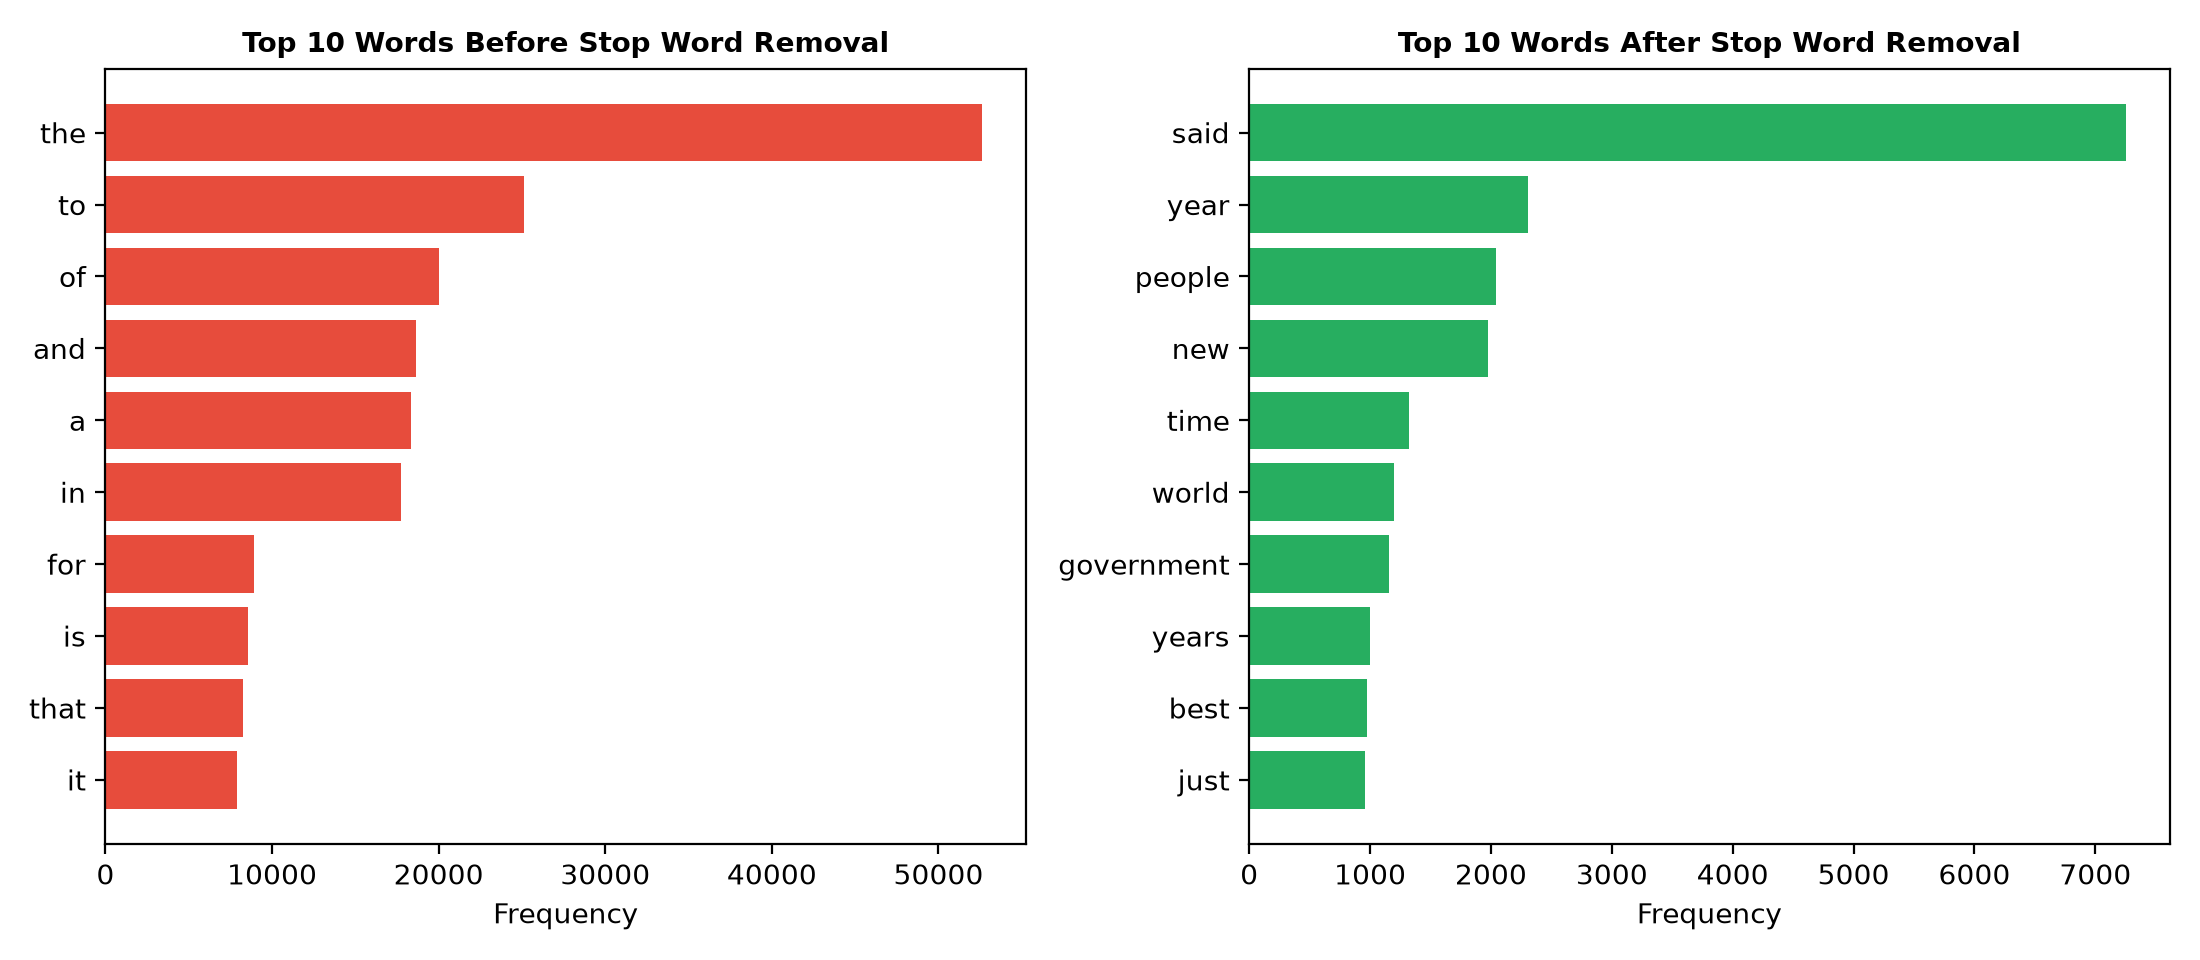

In [6]:
# Visual: Top 10 words before and after stop word removal
plt.figure(figsize=(11, 4.8))
plt.subplot(1, 2, 1)
plt.barh([w[0] for w in reversed(top20_before)], [w[1] for w in reversed(top20_before)], color='#e74c3c')
plt.title('Top 10 Words Before Stop Word Removal', fontsize=10, fontweight='bold')
plt.xlabel('Frequency')

plt.subplot(1, 2, 2)
plt.barh([w[0] for w in reversed(top20_after)], [w[1] for w in reversed(top20_after)], color='#27ae60')
plt.title('Top 10 Words After Stop Word Removal', fontsize=10, fontweight='bold')
plt.xlabel('Frequency')

plt.tight_layout()
plt.show()

**Interpretation:**
- **Left Chart (Before):** The most frequent words were completely generic English grammar words (`'the'`, `'to'`, `'of'`, `'and'`, `'in'`). They tell us nothing about whether an article is about football or business.
- **Right Chart (After):** Meaningful topical words emerge, such as `'said'`, `'year'`, `'mr'`, `'government'`, `'people'`, `'new'`. Removing stop words eliminates 43% of uninformative text tokens, allowing the classifier to focus on real semantic keywords.

### 7. Hand-off to Member 5 (Tokenization & Clean Text Assembly)

In [7]:
# Export for Member 5
df[['category', 'text_no_stops']].to_csv('../results/outputs/step4_no_stopwords_text.csv', index=False)
print("Saved output to: ../results/outputs/step4_no_stopwords_text.csv")
print("Ready for Member 5 (IT25103724 - Tokenization).")

Saved output to: ../results/outputs/step4_no_stopwords_text.csv
Ready for Member 5 (IT25103724 - Tokenization).
